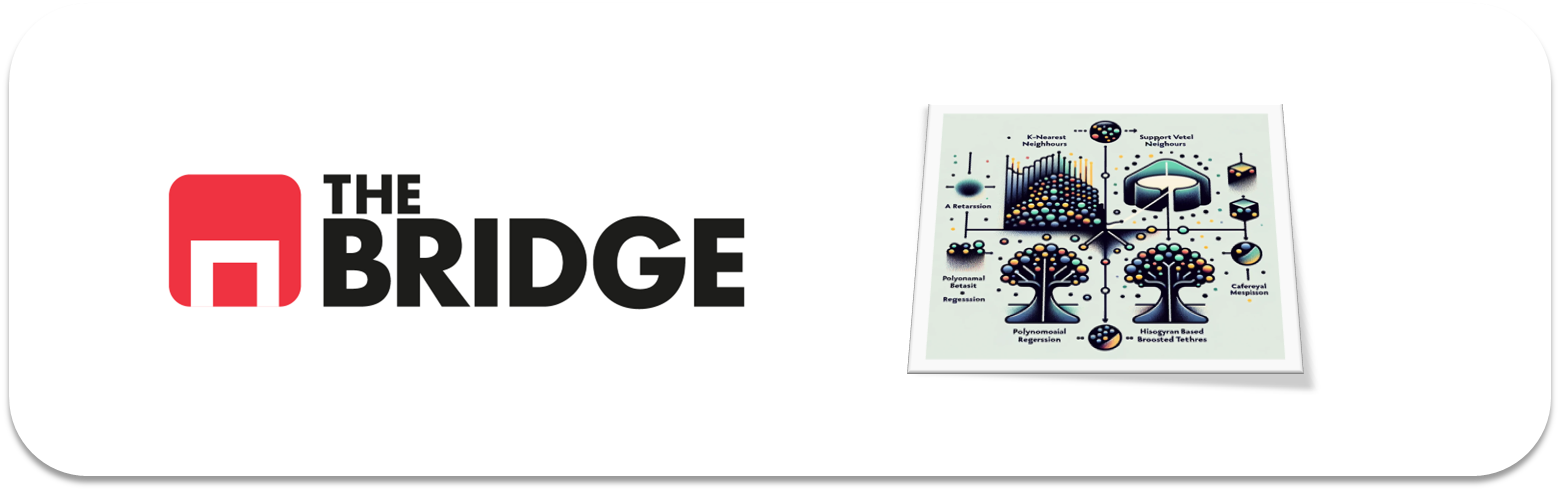

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [11]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, make_scorer, precision_score, ConfusionMatrixDisplay,mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [3]:
df = pd.read_csv('./data/wines_dataset.csv', sep='|')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
target_1 = 'quality'
target_2 = 'alcohol'

array([[<Axes: title={'center': 'quality'}>]], dtype=object)

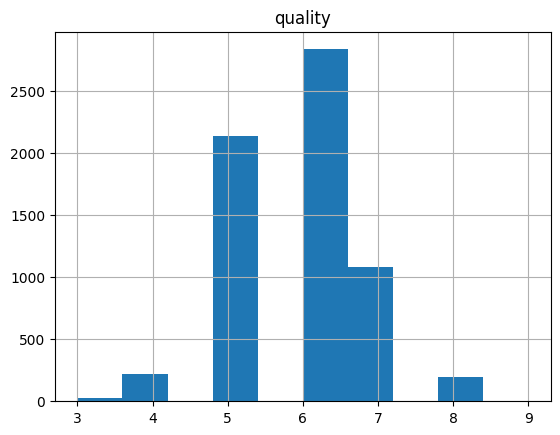

In [9]:
df.hist(target_1)

In [10]:
df[target_1].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

<Axes: xlabel='alcohol', ylabel='Count'>

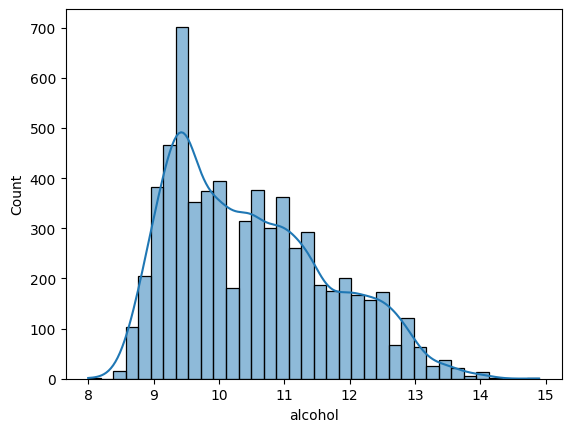

In [8]:
sns.histplot(df[target_2], kde=True)

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [12]:
# split compartido para clasificación y regresión
# stratify con target 1, quality debido a su desbalance

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target_1])

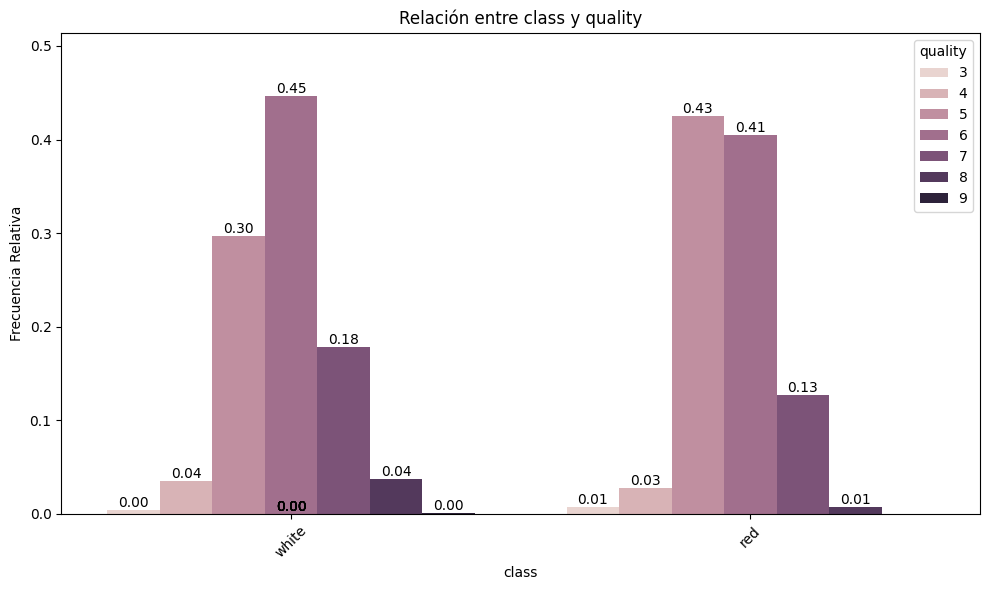

In [13]:
# MiniEDA: Clasificación

# Categóricas

bt.plot_categorical_relationship(train_set, 'class', target_1, show_values=True, relative_freq=True)

In [14]:
feature_cat_clf = ['class']

In [15]:
# Análisis numéricas 

features_num_clf = [col for col in train_set.columns if col != 'class' and col != target_1]
print(len(features_num_clf))

11


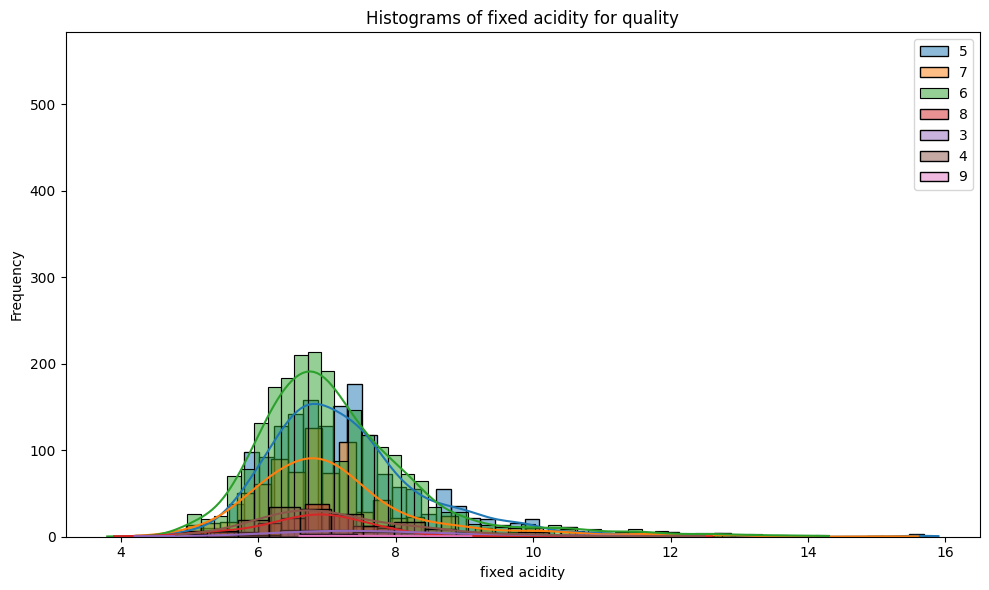

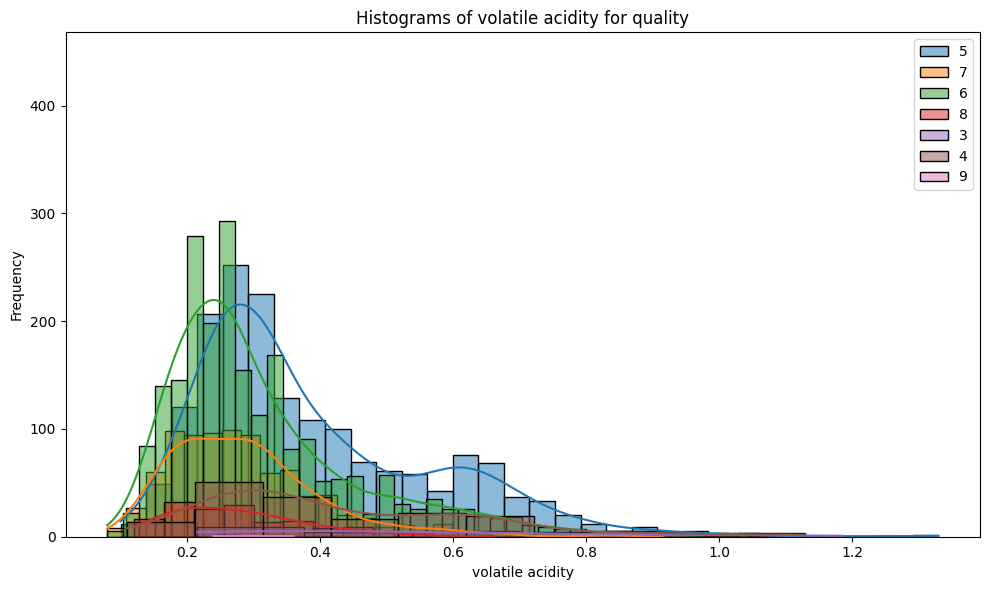

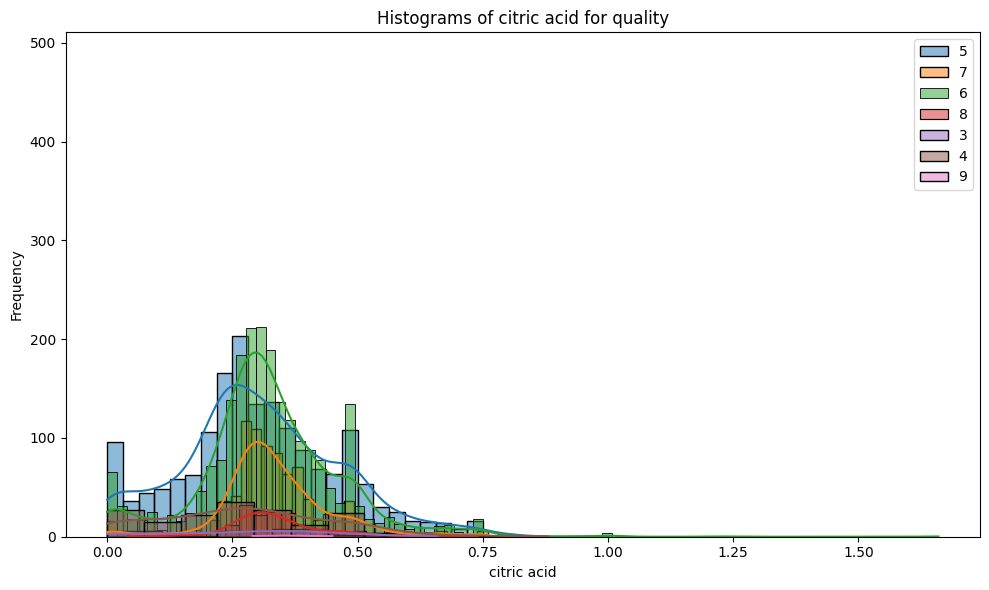

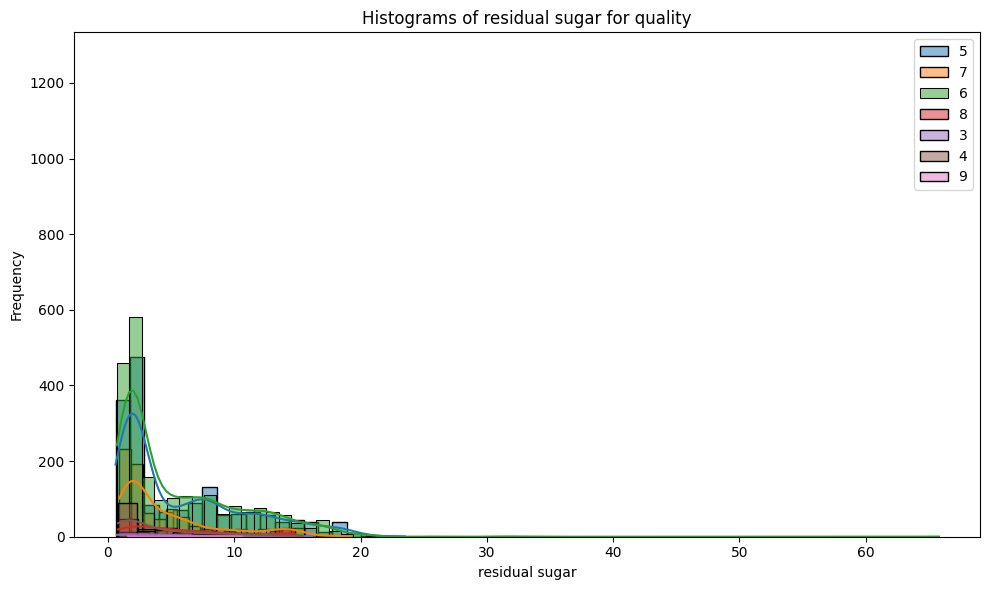

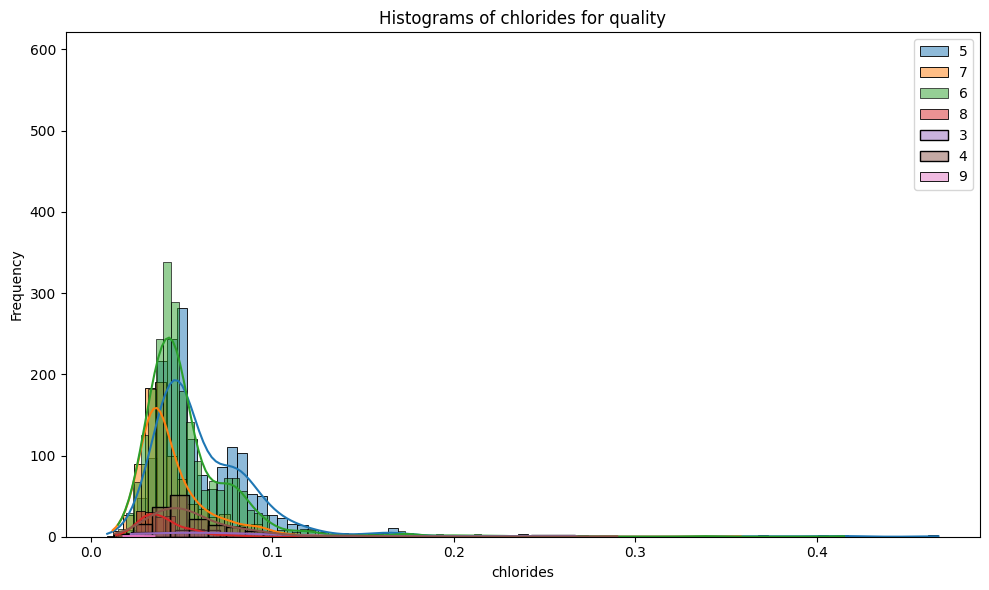

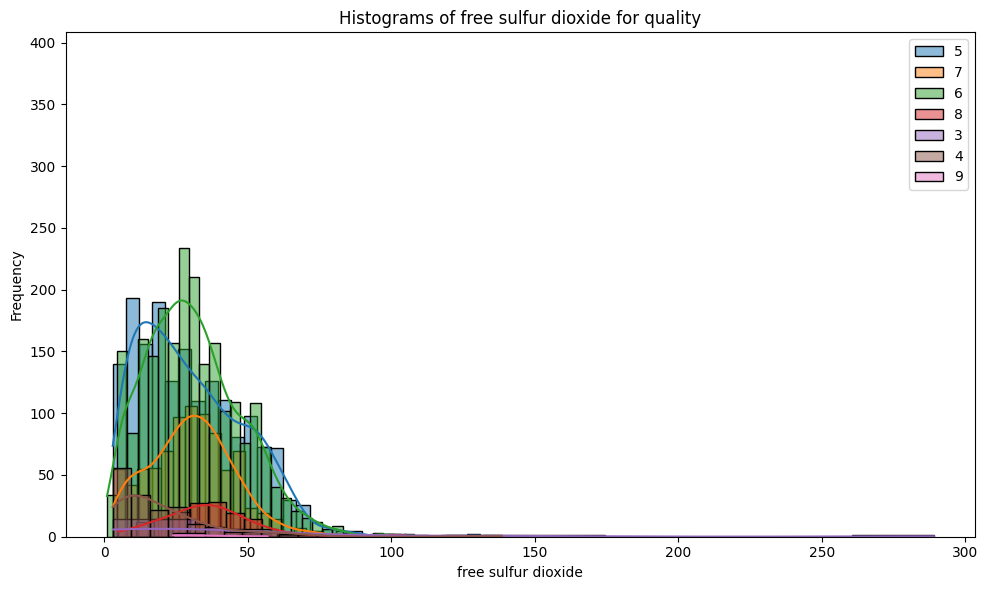

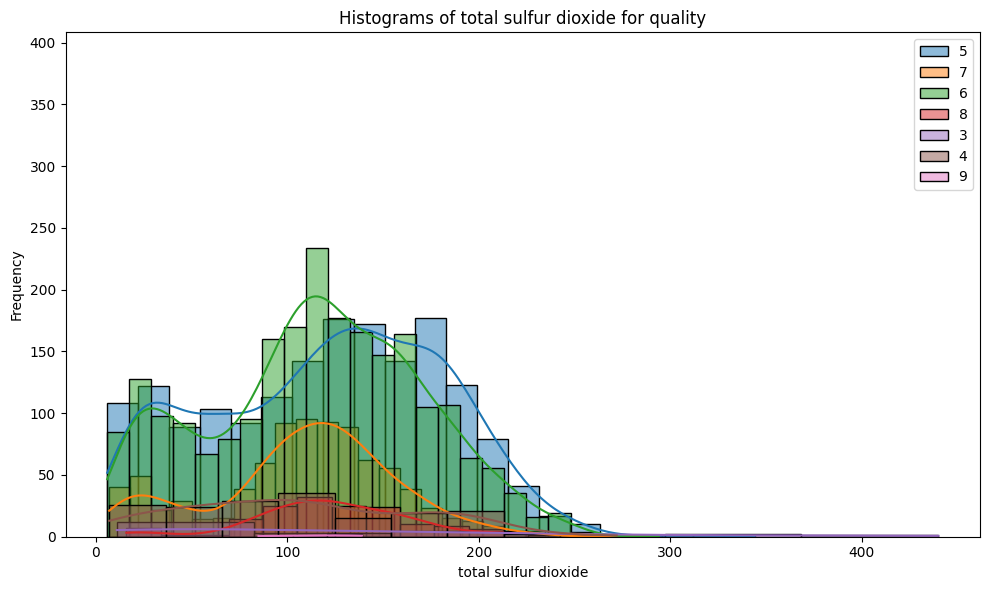

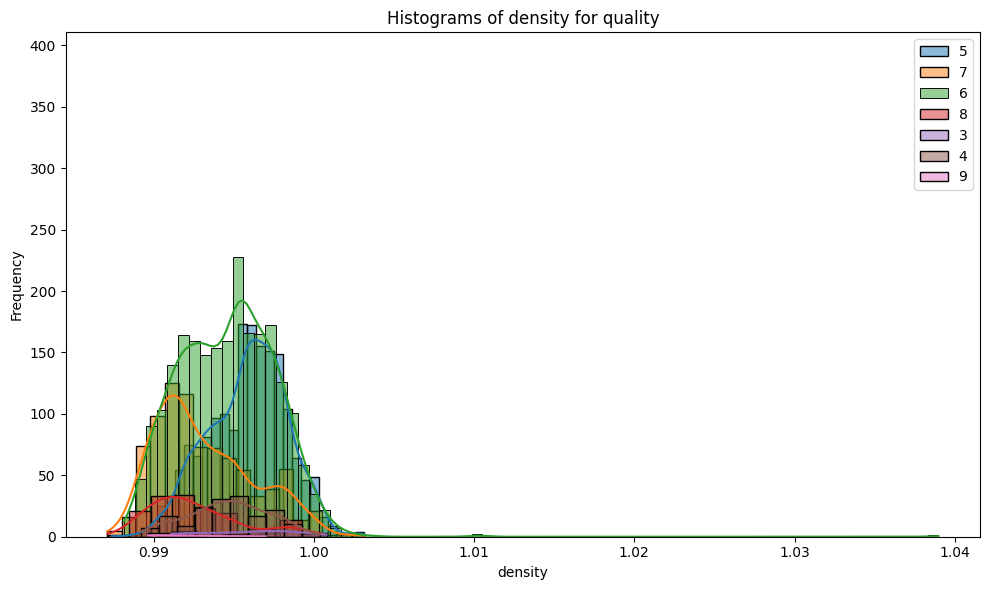

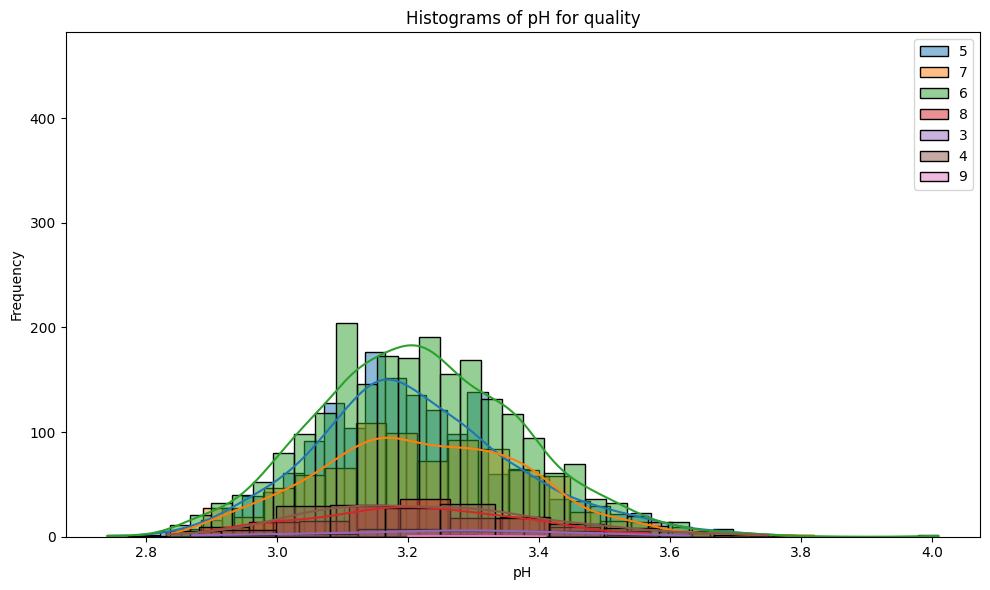

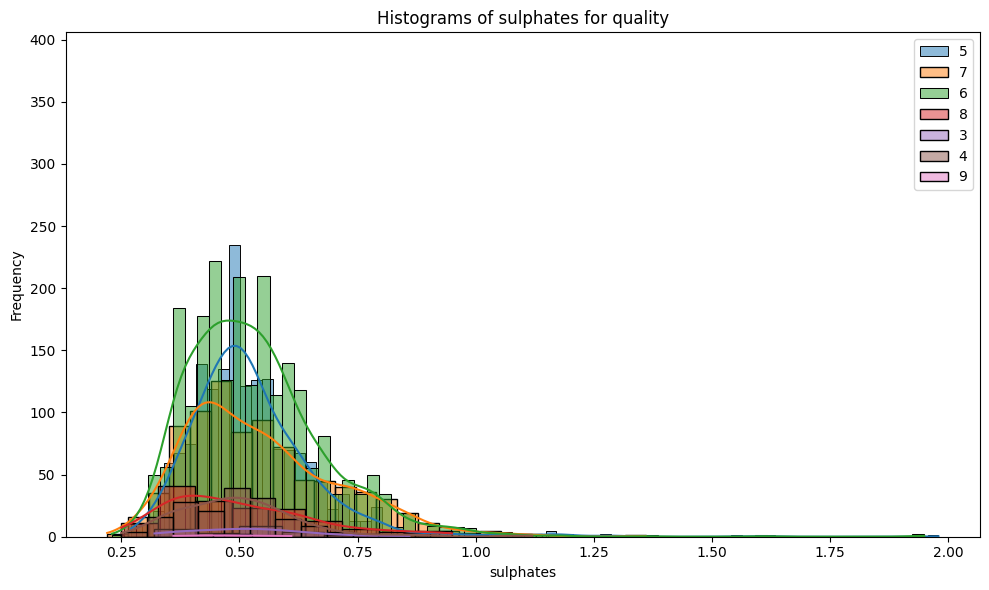

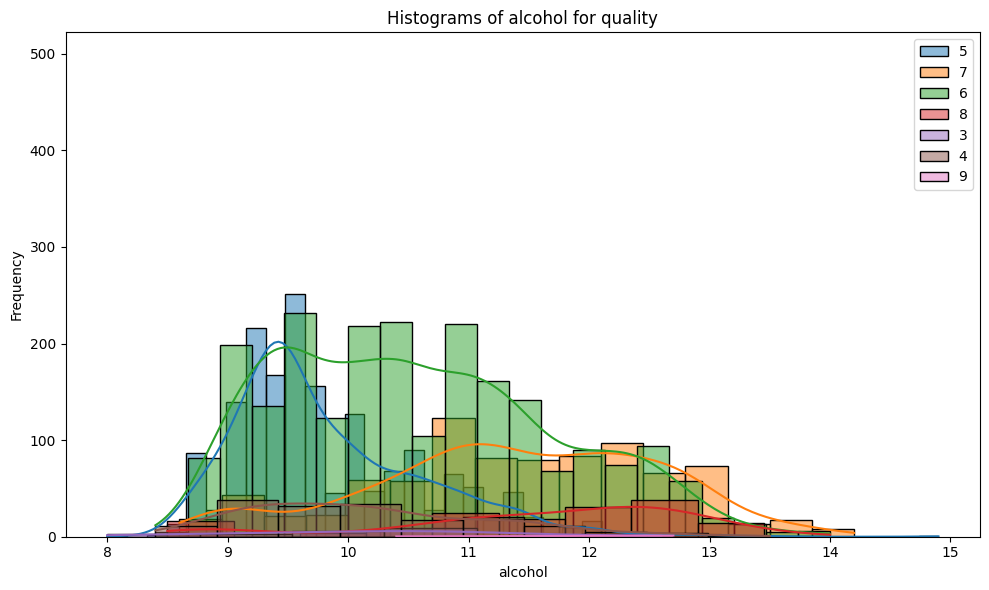

In [16]:
for col in features_num_clf:
    bt.plot_grouped_histograms(train_set, cat_col=target_1, num_col=col, group_size=train_set[target_1].nunique())

*Nos fijamos principalmente en si las curvas son iguales y luego si se cruzan*
*En caso de ser iguales las curvas y no cruzarse, no son relevantes*
*Al contrario ocurre, si existe una asimetría o cruces entre curvas, es más interesante*

In [17]:
features_num_clf_1 = ["volatile acidity","citric acid","chlorides","free sulfur dioxide","total sulfur dioxide", "density","sulphates","alcohol"]
features_num_clf_2 = ["fixed acidity","residual sugar","pH"]

MiniEDA Regresión

In [18]:
features_cat_reg = ["class", "quality"]
features_cat_reg

['class', 'quality']

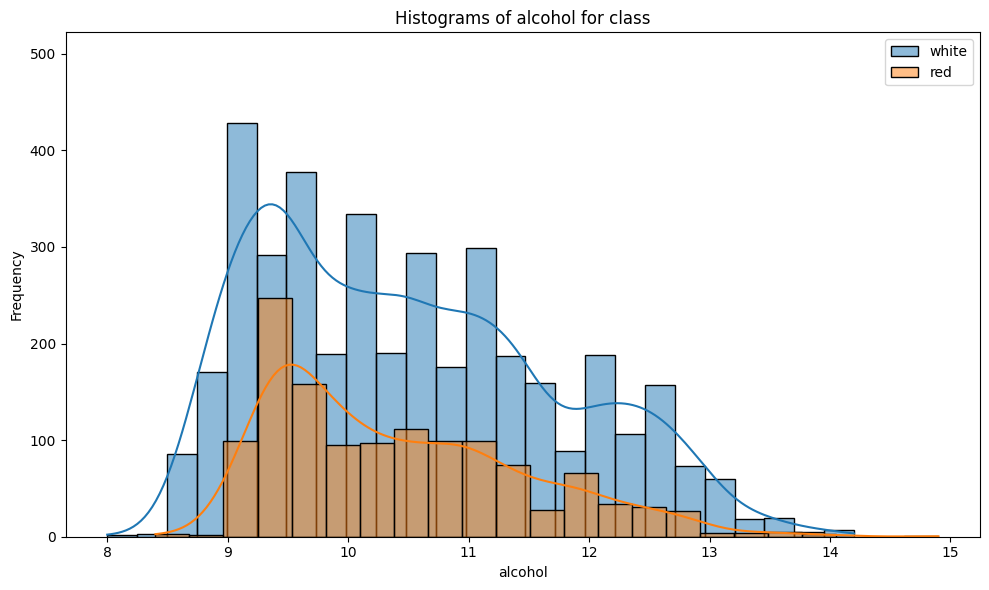

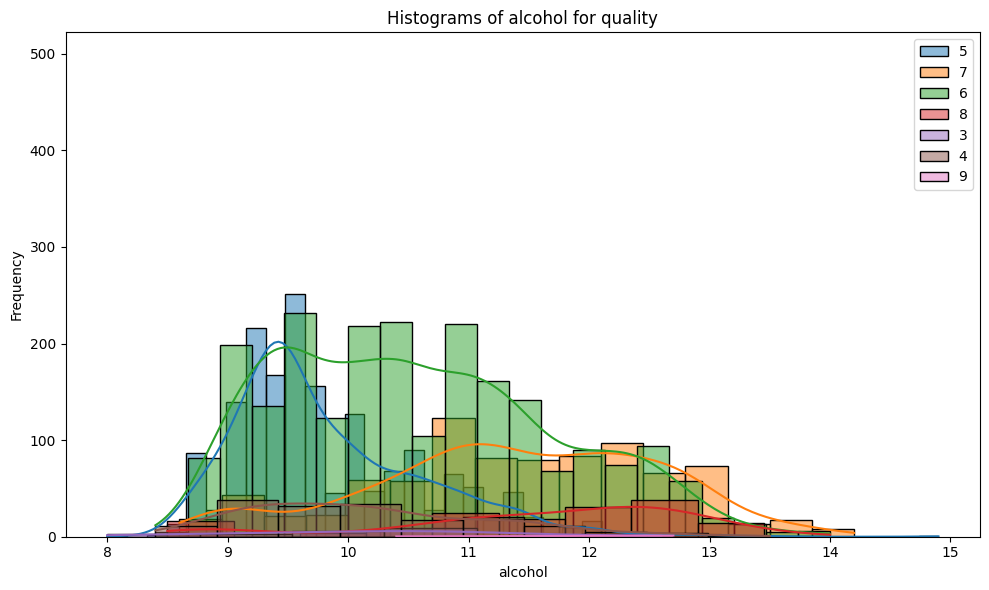

In [20]:
# Categóricas: class y quality

# Quality y alcohol ya la hemos visto antes al estudiar el bivariante del problema de clasificación: es la última gráfica y parece que sí hay relación.

for col in features_cat_reg:
    bt.plot_grouped_histograms(train_set, cat_col= col, num_col= target_2, group_size= train_set[col].nunique())

In [21]:
features_cat_reg = ["class","quality"]

In [22]:
features_num_reg = [col for col in train_set.columns if col not in features_cat_reg]
features_num_reg

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [23]:
# Estudiamos ahora las correlaciones y el mapa de correlaciones

corr = train_set[features_num_reg].corr(numeric_only= "True")
serie_corr = np.abs(corr[target_2]).sort_values(ascending = False)
serie_corr

alcohol                 1.000000
density                 0.683073
residual sugar          0.361373
total sulfur dioxide    0.265385
chlorides               0.260342
free sulfur dioxide     0.175778
pH                      0.113848
fixed acidity           0.085195
volatile acidity        0.043211
sulphates               0.005453
citric acid             0.004981
Name: alcohol, dtype: float64

*Nos interesan los que tengan una correlación superior al 0.1, siendo poco exigentes*

In [24]:
r_min = 0.10

features_num_reg_1 = serie_corr[serie_corr > r_min].index.to_list()
features_num_reg_1.remove(target_2)

features_num_reg_2 = [col for col in train_set.columns if col not in features_num_reg_1 and col != target_2
                       and col not in features_cat_reg]

<Axes: >

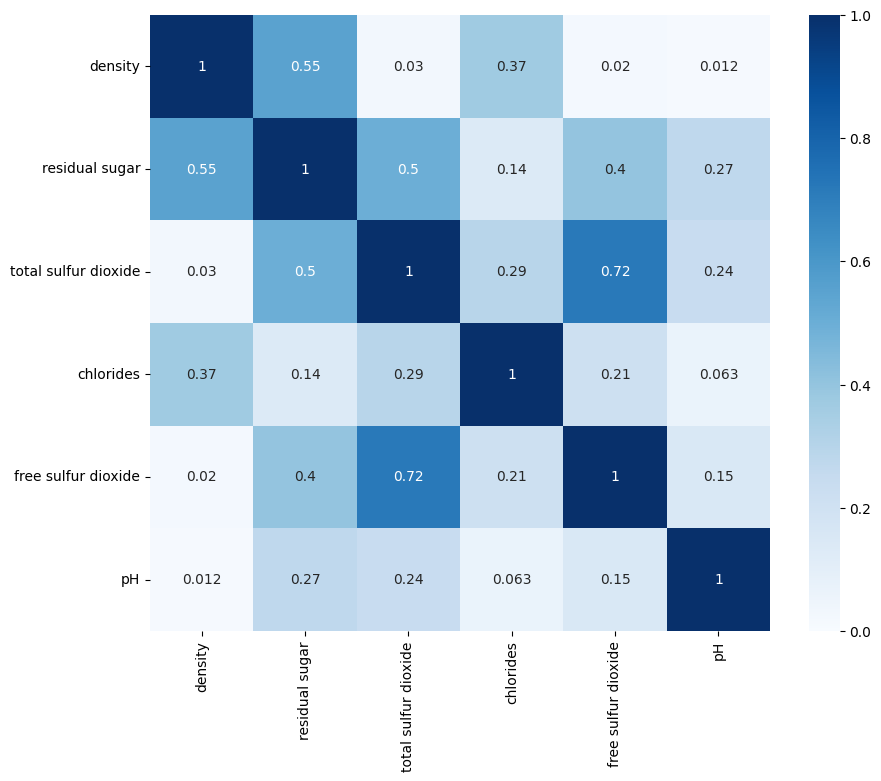

In [25]:
plt.figure(figsize= (10,8))
sns.heatmap(np.abs(train_set[features_num_reg_1].corr(numeric_only= "True")), annot= True, cmap = "Blues", vmin= 0, vmax= 1)

*Se observan las correlaciones más altas para evitar multicolinealidad*

In [26]:
features_num_reg_1.remove("free sulfur dioxide") # Es la que menos correla con alcohol.
features_num_reg_2.append("free sulfur dioxide")

Tratamiento features:

In [27]:
train_set["class"] = (train_set["class"] == "white").astype(int) # white -> clase 1, red -> clase 0
test_set["class"] = (test_set["class"] == "white").astype(int) # white -> clase 1, red -> clase 0

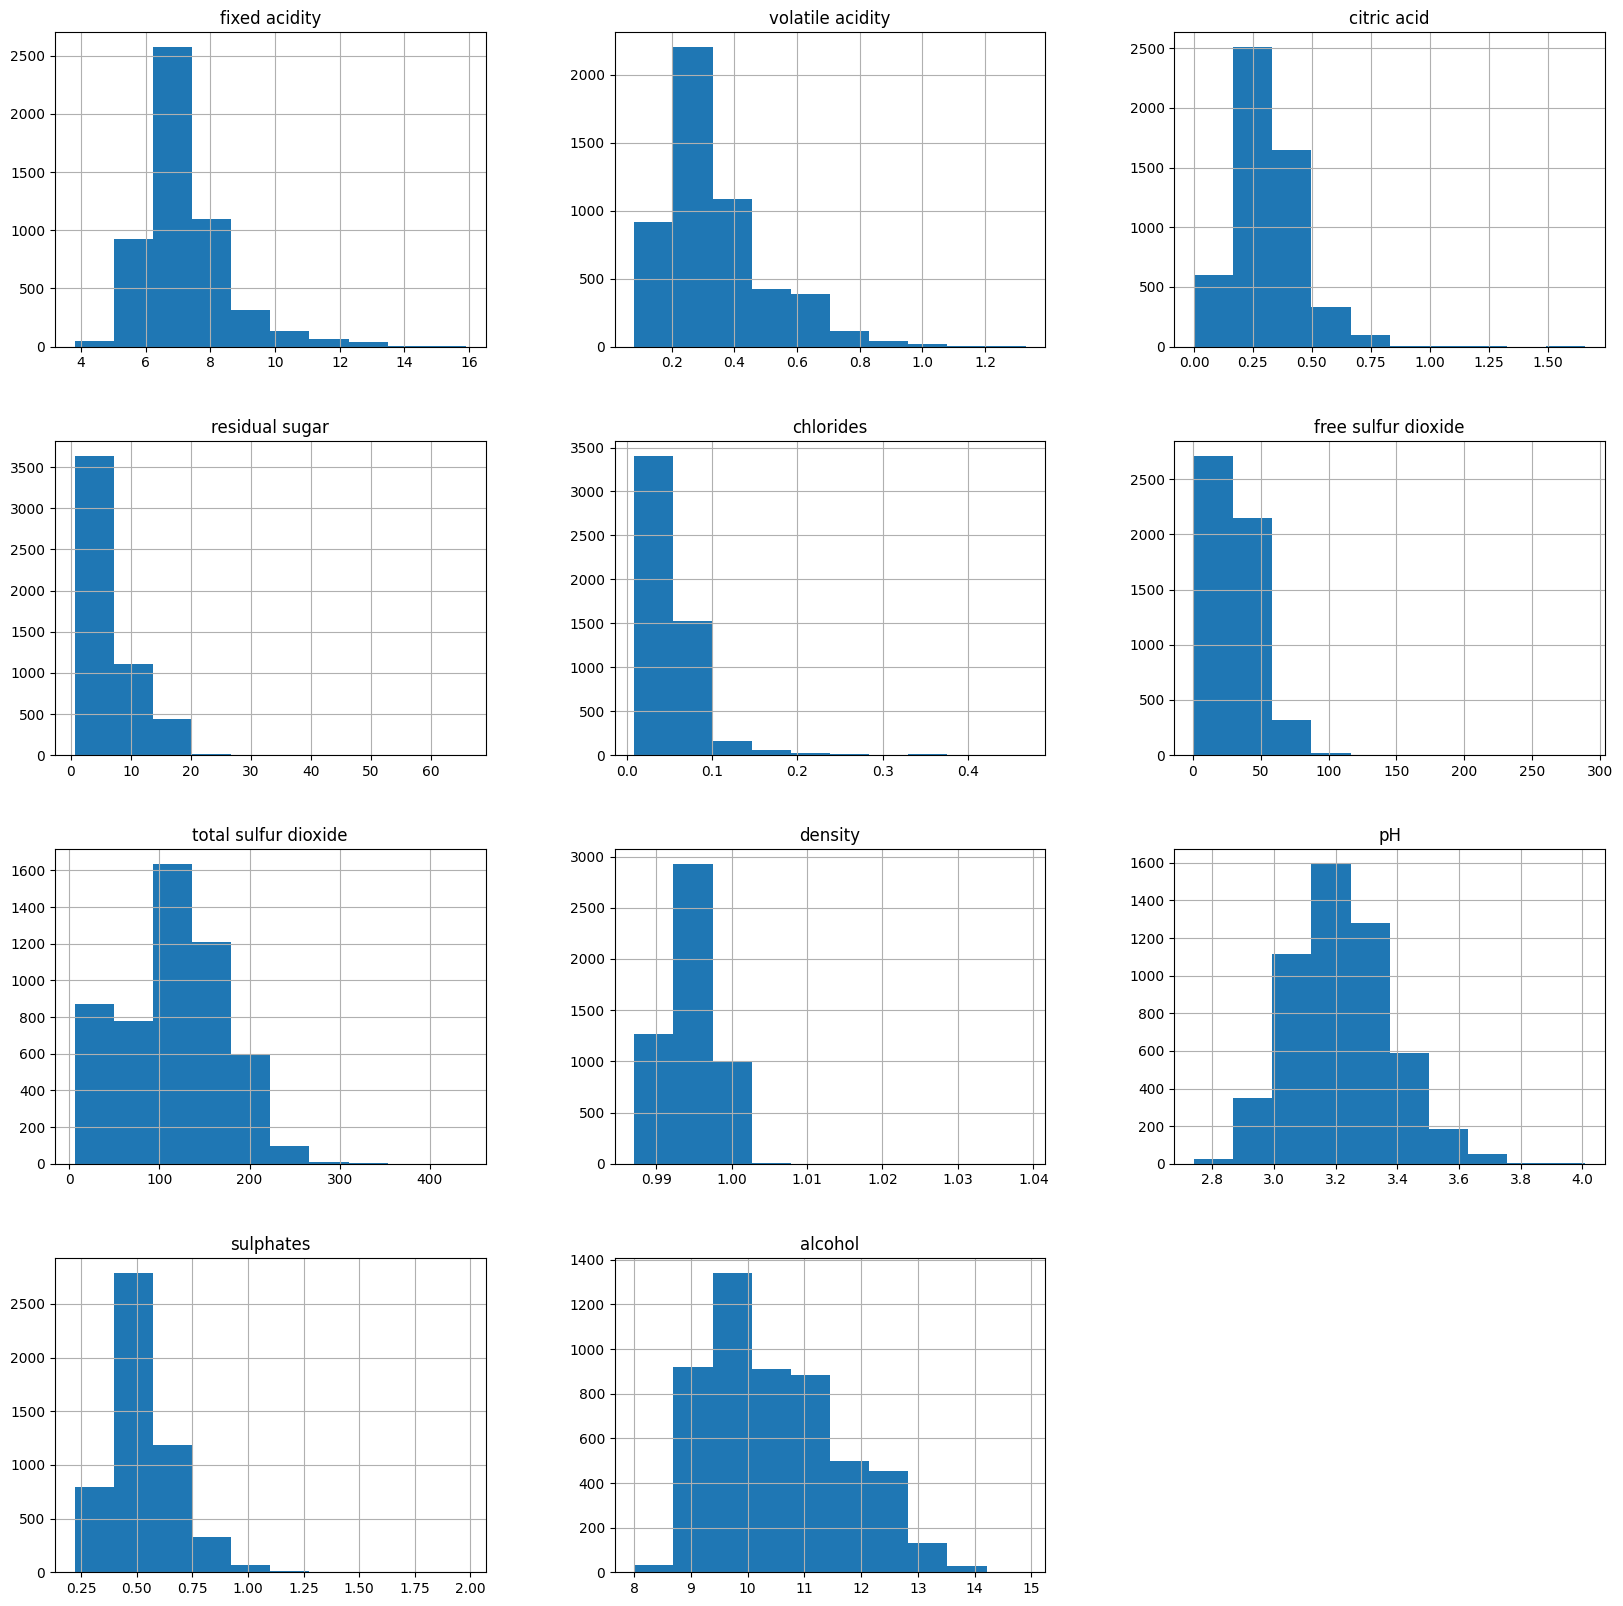

In [28]:
train_set[features_num_clf].hist(figsize=(20,20))
plt.tight_layout
plt.show()

<Axes: xlabel='alcohol', ylabel='Count'>

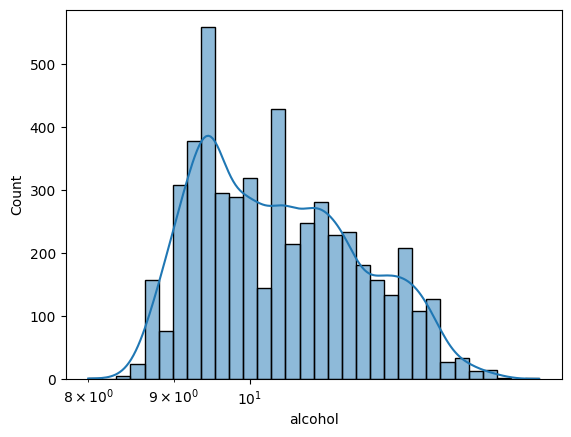

In [29]:
sns.histplot(train_set["alcohol"], kde=True, log_scale=10)

In [30]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

In [31]:
features_to_transform = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar", 
    "chlorides",
    "free sulfur dioxide", 
    "total sulfur dioxide",
    "sulphates"
    ]

In [32]:
# Aplica una transformación logarítmica a las columnas seleccionadas,
# desplazando los valores si es necesario para evitar log(0) o log de negativos
for col in features_to_transform:
    desplaza = 0
    if train_set_scaled[col].min() <= 0:
        desplaza = int(abs(train_set_scaled[col].min())) + 1
    train_set_scaled[col] = np.log(train_set_scaled[col] + desplaza)
    test_set_scaled[col] = np.log(test_set_scaled[col] + desplaza)

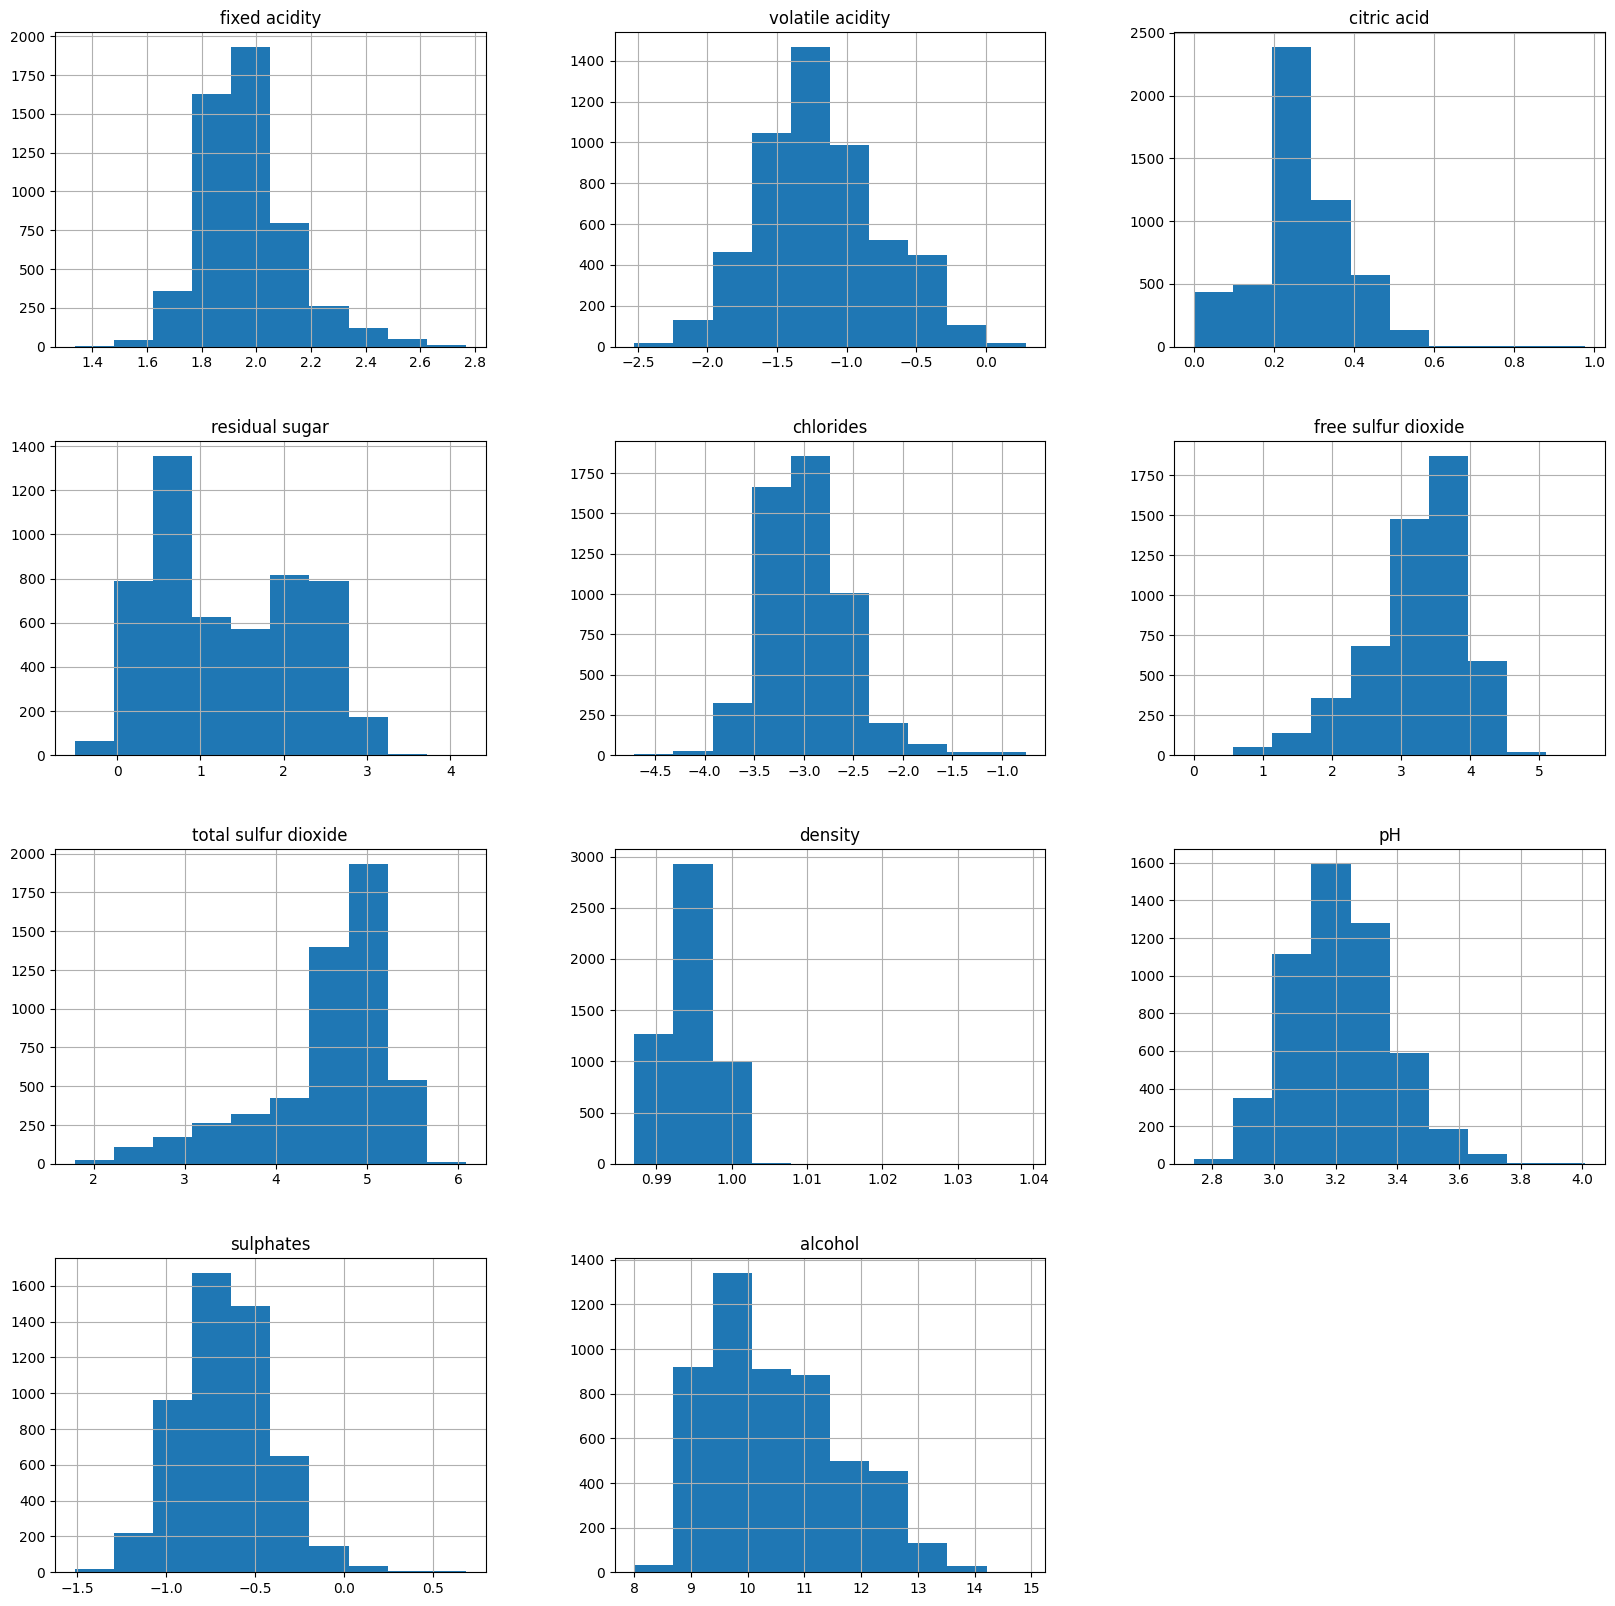

In [33]:
train_set_scaled[features_num_clf].hist(figsize = (20,20))
plt.tight_layout
plt.show()

**

In [34]:
scaler = StandardScaler()

features_num_reg = features_num_clf.copy()
features_num_reg.remove("alcohol") # Alcohol es nuestro target

train_set_scaled[features_num_reg] = scaler.fit_transform(train_set_scaled[features_num_reg])
test_set_scaled[features_num_reg] = scaler.transform(test_set_scaled[features_num_reg])


In [36]:
train_set_scaled_clf = train_set_scaled.copy()
test_set_scaled_clf = test_set_scaled.copy()

train_set_scaled_clf["alcohol"] = scaler.fit_transform(train_set_scaled_clf[["alcohol"]])
test_set_scaled_clf["alcohol"] = scaler.transform(test_set_scaled_clf[["alcohol"]])

In [37]:
# Clasificación
y_train_clf = train_set[target_1]
y_test_clf = test_set[target_1]

#Regresión
y_train_reg = train_set[target_2]
y_test_reg = test_set[target_2]

# clasificación
X_train_clf_dict = {}
X_test_clf_dict = {}

#Regresión
X_train_reg_dict = {}
X_test_reg_dict = {}

# Juegos X_train clasificacion

features_set_name = ["cat+num_1", "todas"]
features_set = [feature_cat_clf + features_num_clf_1,
                feature_cat_clf + features_num_clf_1 + features_num_clf_2]


for set_name,feature_list in zip(features_set_name, features_set):
    print(feature_list)
    X_train_clf_dict[set_name] = train_set_scaled_clf[feature_list]
    X_test_clf_dict[set_name] = test_set_scaled_clf[feature_list]

## ----------------------------------- ##
# Juegos X_train regresion
    
features_set_name = ["cat+num_1","todas"]
features_set = [features_cat_reg + features_num_reg_1,
                features_cat_reg + features_num_reg_1 + features_num_reg_2]

for set_name,feature_list in zip(features_set_name, features_set):
    print(feature_list)
    X_train_reg_dict[set_name] = train_set_scaled[feature_list]
    X_test_reg_dict[set_name] = test_set_scaled[feature_list]

['class', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']
['class', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol', 'fixed acidity', 'residual sugar', 'pH']
['class', 'quality', 'density', 'residual sugar', 'total sulfur dioxide', 'chlorides', 'pH']
['class', 'quality', 'density', 'residual sugar', 'total sulfur dioxide', 'chlorides', 'pH', 'fixed acidity', 'volatile acidity', 'citric acid', 'sulphates', 'free sulfur dioxide']


BASELINE

In [38]:
from sklearn.tree import DecisionTreeClassifier

# Instanciamos modelos — añadimos DecisionTree para completar el repaso:
# árbol individual → enseña el concepto de splits y max_depth;
# el ensemble (RF, LGB) lo mejora porque promedia muchos árboles descorrelados.
knn_clf        = KNeighborsClassifier(n_neighbors=5)
knn_ten_clf    = KNeighborsClassifier(n_neighbors=10)
lr_clf         = LogisticRegression(max_iter=1000)
dt_clf         = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_clf         = RandomForestClassifier(max_depth=10, random_state=42)
lgb_clf        = LGBMClassifier(max_depth=10, random_state=42, verbose=-1, n_jobs=-1)

modelos_clf = {
    "KNN_5":               knn_clf,
    "KNN_10":              knn_ten_clf,
    "Regresion Logistica": lr_clf,
    "Decision Tree":       dt_clf,
    "Random Forest":       rf_clf,
    "LightGBM":            lgb_clf
}

In [39]:
for feature_set, X_train in X_train_clf_dict.items():
    print(f"Para el set {feature_set}:")
    for tipo,modelo in modelos_clf.items():
        print(f"{tipo}: ", end = " ")
        print(np.mean(cross_val_score(modelo, X_train, y_train_clf, cv = 5, scoring = "balanced_accuracy"))) 
    print("******")

Para el set cat+num_1:
KNN_5:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.27678066803077755
KNN_10:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.2569408254740313
Regresion Logistica:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.23502999521538329
Decision Tree:  0.2229518734633619
Random Forest:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.29932781587806556
LightGBM:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.36236061574801054
******
Para el set todas:
KNN_5:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.28201413297629346
KNN_10:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.2549186132910148
Regresion Logistica:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.23495339176939473
Decision Tree:  0.22679255632324202
Random Forest:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.2873590933510206
LightGBM:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.3686583495047858
******


**

In [40]:
# class_weight='balanced' ajusta los pesos de cada clase inversamente
# proporcional a su frecuencia. Para DecisionTree, el efecto es el mismo:
# penaliza más los errores en clases minoritarias durante la construcción del árbol.
knn_clf        = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_ten_clf    = KNeighborsClassifier(n_neighbors=10, weights="distance")
lr_clf         = LogisticRegression(max_iter=1000, class_weight="balanced")
dt_clf         = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
rf_clf         = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")
lgb_clf        = LGBMClassifier(max_depth=10, random_state=42, verbose=-1,
                                class_weight="balanced", n_jobs=-1)

modelos_clf = {
    "KNN_5":               knn_clf,
    "KNN_10":              knn_ten_clf,
    "Regresion Logistica": lr_clf,
    "Decision Tree":       dt_clf,
    "Random Forest":       rf_clf,
    "LightGBM":            lgb_clf
}

In [41]:
for feature_set, X_train in X_train_clf_dict.items():
    print(f"Para el set {feature_set}:")
    for tipo,modelo in modelos_clf.items():
        print(f"{tipo}: ", end = " ")
        print(np.mean(cross_val_score(modelo, X_train, y_train_clf, cv = 5, scoring = "balanced_accuracy")))
    print("******")

Para el set cat+num_1:
KNN_5:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.36752532996827536
KNN_10:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.364379182289076
Regresion Logistica:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


0.32989470620198447
Decision Tree:  0.27643186611560244
Random Forest:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.37102110652487263
LightGBM:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.3850051995055829
******
Para el set todas:
KNN_5:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.3694238399902181
KNN_10:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.36330368073957386
Regresion Logistica:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


0.37748439543325246
Decision Tree:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


0.2685598481266669
Random Forest:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.3717148922746332
LightGBM:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


0.3870755454551817
******


In [42]:
param_grid = {
    "n_estimators": [100,200,1000],
    "max_depth": [1,5,10,20],
    "learning_rate": [0.1,0.3,0.6,1,0.01],
    "class_weight": ["balanced"]
}

# random_state en el estimador base: el random_state de GridSearchCV
# solo controla los splits de CV, no la aleatoriedad interna de LightGBM.
lgb_clf = LGBMClassifier(verbose=-1, n_jobs=-1, random_state=42)

lgb_grid = GridSearchCV(lgb_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring = "balanced_accuracy")

lgb_grid.fit(X_train_clf_dict["todas"], y_train_clf)

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:29

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'learning_rate': [0.1, 0.3, ...], 'max_depth': [1, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [43]:
print(lgb_grid.best_params_)
print(lgb_grid.best_score_)

{'class_weight': 'balanced', 'learning_rate': 0.01, 'max_depth': 20, 'n_estimators': 200}
0.3960227652257431


In [44]:
print(lgb_grid.get_params()) # Nos ofrece los parametros de GridSearch, no los del modelo evaluado

{'cv': 5, 'error_score': nan, 'estimator__boosting_type': 'gbdt', 'estimator__class_weight': None, 'estimator__colsample_bytree': 1.0, 'estimator__importance_type': 'split', 'estimator__learning_rate': 0.1, 'estimator__max_depth': -1, 'estimator__min_child_samples': 20, 'estimator__min_child_weight': 0.001, 'estimator__min_split_gain': 0.0, 'estimator__n_estimators': 100, 'estimator__n_jobs': -1, 'estimator__num_leaves': 31, 'estimator__objective': None, 'estimator__random_state': 42, 'estimator__reg_alpha': 0.0, 'estimator__reg_lambda': 0.0, 'estimator__subsample': 1.0, 'estimator__subsample_for_bin': 200000, 'estimator__subsample_freq': 0, 'estimator__verbose': -1, 'estimator': LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1), 'n_jobs': None, 'param_grid': {'n_estimators': [100, 200, 1000], 'max_depth': [1, 5, 10, 20], 'learning_rate': [0.1, 0.3, 0.6, 1, 0.01], 'class_weight': ['balanced']}, 'pre_dispatch': '2*n_jobs', 'refit': True, 'return_train_score': False, 'scoring': 'bal

In [45]:
lgb_grid.best_estimator_

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,20
,learning_rate,0.01
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
lgb_grid.best_estimator_.feature_importances_

array([ 166, 4515, 2604, 3870, 4667, 3772, 2702, 3112, 5113, 3814, 4264,
       3378], dtype=int32)

**

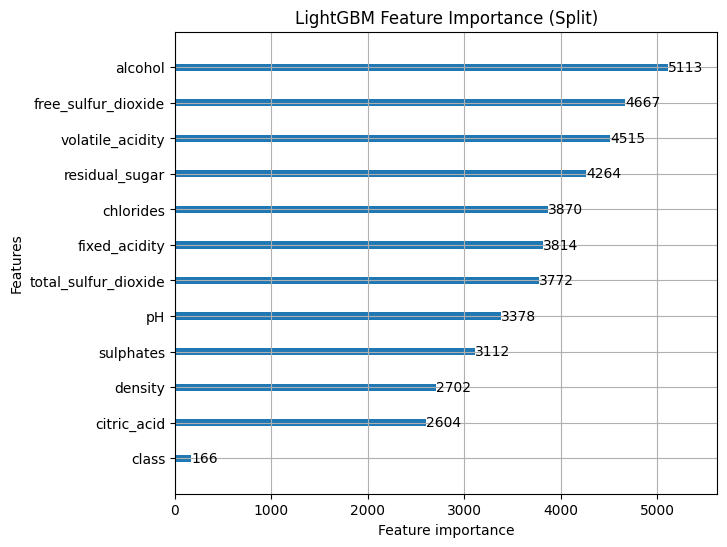

In [47]:
from lightgbm import plot_importance

# Genera un gráfico de importancia de características usando el modelo LightGBM entrenado.
# importance_type="split": cuenta cuántas veces se ha utilizado cada feature para dividir los nodos de los árboles.
# Esto nos indica qué variables son más relevantes para la predicción, aunque no nos dice cuánto mejoran la predicción.

plot_importance(lgb_grid.best_estimator_,
                importance_type="split",
                figsize=(7,6),
                title="LightGBM Feature Importance (Split)")
plt.show()

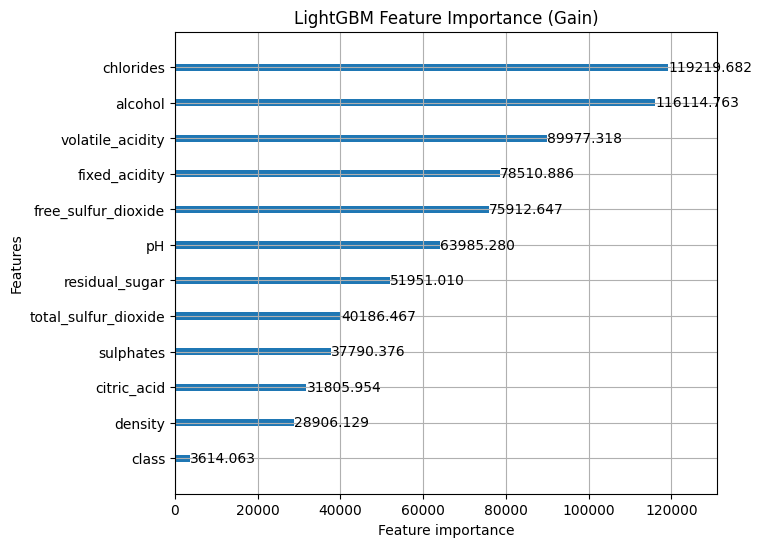

In [48]:
# importance_type="gain": calcula cuánto mejora la función objetivo cada feature cuando se usa para dividir nodos.
# Esto nos indica qué variables contribuyen más a mejorar la precisión del modelo.

plot_importance(lgb_grid.best_estimator_,
                importance_type="gain",
                figsize=(7,6),
                title="LightGBM Feature Importance (Gain)")
plt.show()

Evaluación contra test + matriz confusión (entender errores)

**

In [49]:
y_pred = lgb_grid.best_estimator_.predict(X_test_clf_dict["todas"])
# print(classification_report(y_test_clf, y_pred))
print(classification_report(y_test_clf, y_pred, zero_division= 0.0)) # Sin warnings

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.18      0.49      0.26        43
           5       0.64      0.63      0.63       428
           6       0.63      0.38      0.47       567
           7       0.39      0.58      0.47       216
           8       0.20      0.46      0.28        39
           9       0.00      0.00      0.00         1

    accuracy                           0.50      1300
   macro avg       0.29      0.36      0.30      1300
weighted avg       0.56      0.50      0.51      1300



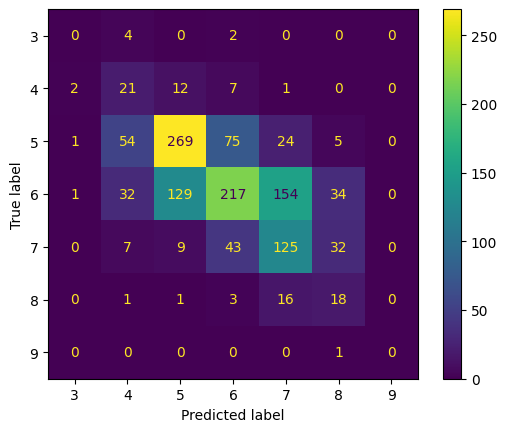

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test_clf, y_pred)
# ConfusionMatrixDisplay.from_predictions(y_test_clf, y_pred)
plt.show()

**

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Baseline lineal: si el MAPE de LinearRegression ya es bajo,
# el problema era esencialmente lineal y los ensembles no aportan mucho.
# Si los ensembles mejoran claramente, la relación es no lineal — y tiene sentido usarlos.
lr_reg  = LinearRegression()
dt_reg  = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_reg  = RandomForestRegressor(max_depth=10, random_state=42)
lgb_reg = LGBMRegressor(max_depth=10, random_state=42, verbose=-1)
xgb_reg = XGBRegressor(max_depth=10, random_state=42)

modelos_reg = {
    "Regresion Lineal":    lr_reg,
    "Decision Tree":       dt_reg,
    "Random Forest":       rf_reg,
    "LightGBM":            lgb_reg,
    "XGBoost Regressor":   xgb_reg
}

In [52]:
for feature_set, X_train in X_train_reg_dict.items():
    print(f"Para el set {feature_set}:")
    for tipo,modelo in modelos_reg.items():
        print(f"{tipo}: ", end = " ")
        print(-np.mean(cross_val_score(modelo, X_train, y_train_reg, cv = 5, scoring = "neg_mean_absolute_percentage_error"))) # MAPE = 0.024 -> ¿bueno o malo? 2,4% de error! 
    print("******")

Para el set cat+num_1:
Regresion Lineal:  0.048973186698582014
Decision Tree:  0.048640847194771394
Random Forest:  0.0355660030629474
LightGBM:  

c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\maxim\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\maxim\AppData\Local\Programs\

0.03545169087258895
XGBoost Regressor:  0.03113373359745362
******
Para el set todas:
Regresion Lineal:  0.04017013943622131
Decision Tree:  0.04873209083625202
Random Forest:  0.03012867407192817
LightGBM:  0.02656499193817987
XGBoost Regressor:  0.024315098906614128
******


*En scikit-learn los valores del MAPE son del 0 al 1 y no del 0 al 100.*

*Nos fijamos en el que haya un menor error, si utilizando todas la variables o algunas, según que modelo y su simplicidad*

In [53]:
param_grid = {
    "n_estimators": [100,200,1000],
    "max_depth": [1,5,10,20],
    "max_features": ["log2","sqrt", None]
}

# random_state en el estimador base para reproducibilidad del bootstrap
# y la selección aleatoria de features en cada split.
rf_reg = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(rf_reg,
                       param_grid= param_grid,
                       cv = 5,
                       scoring = "neg_mean_absolute_percentage_error",
                       n_jobs= -1)

rf_grid.fit(X_train_reg_dict["todas"], y_train_reg)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 5, ...], 'max_features': ['log2', 'sqrt', ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [54]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': 20, 'max_features': None, 'n_estimators': 1000}
-0.025964772517517155


In [55]:
y_pred = rf_grid.best_estimator_.predict(X_test_reg_dict["todas"])
print("MAPE:", mean_absolute_percentage_error(y_test_reg, y_pred))

MAPE: 0.025297952377842124


In [56]:
# Función para regresión
def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

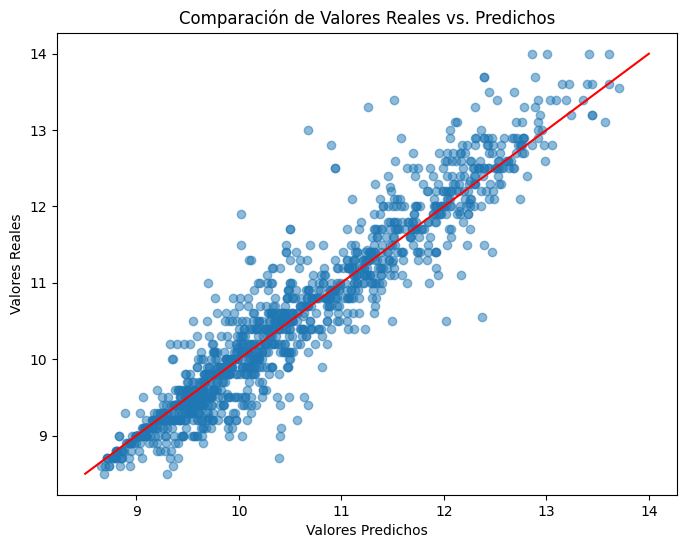

In [57]:
plot_predictions_vs_actual(y_test_reg, y_pred)

*siempre desconfiar de los modelos perfectos, donde todos los valores por ejemplo se concentren en la linea roja*

In [58]:
pd.DataFrame({"features": rf_grid.best_estimator_.feature_names_in_ , "importance": rf_grid.best_estimator_.feature_importances_}).sort_values("importance",ascending=False)

,features,importance
2,density,0.604569
3,residual sugar,0.101977
4,total sulfur dioxide,0.053108
7,fixed acidity,0.041489
0,class,0.037598
6,pH,0.030126
5,chlorides,0.029620
9,citric acid,0.024402
10,sulphates,0.022533
1,quality,0.021784


PERSISTENCIA MODELO EN DISCO

In [59]:
import pickle

# Guardar el modelo en un archivo con extensión .pkl
with open('rf_model.pkl', 'wb') as file:
    pickle.dump(rf_grid.best_estimator_, file)

In [60]:
# Cargar el modelo
with open('rf_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [61]:
loaded_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample